<a href="https://colab.research.google.com/github/JayanthM31/Nueral_Network/blob/main/Neural_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate Abaqus Data for a CT Specimen (Aluminum)
def create_synthetic_abaqus_data():
    # Parameters for Al 2024-T3
    C = 1.2e-10
    m = 3.2
    delta_sigma = 80 # MPa
    a_init = 10.0    # 10mm initial crack
    N = np.linspace(0, 50000, 100) # 50,000 cycles

    # Simple integration of Paris Law for data generation
    # a = [a_i^(1-m/2) + (1-m/2) * C * (delta_sigma * sqrt(pi))^m * N] ^ (1/(1-m/2))
    a = a_init + (C * (delta_sigma * np.sqrt(np.pi * a_init/1000))**m) * N * 1000

    df = pd.DataFrame({'Cycles': N, 'Crack_Length_mm': a})
    df.to_csv('abaqus_data.csv', index=False)
    return df

data = create_synthetic_abaqus_data()
print("Synthetic Abaqus CSV Created and Loaded!")
data.head()

Synthetic Abaqus CSV Created and Loaded!


,Cycles,Crack_Length_mm
0,0.000000,10.000000
1,505.050505,10.293659
2,1010.101010,10.587319
3,1515.151515,10.880978
4,2020.202020,11.174637


In [ ]:
class FatiguePINN(nn.Module):
    def __init__(self):
        super(FatiguePINN, self).__init__()
        # 4 Layers, 50 Neurons each
        self.net = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1),
            nn.Sigmoid() # Change ReLU to Sigmoid to ensure output is between 0 and 1
        )

    def forward(self, n):
        return self.net(n)

def calculate_physics_loss(model, n_tensor_scaled, a_max, N_max):
    # Detach and then set requires_grad=True to make it a leaf tensor for this calculation
    n_tensor_scaled = n_tensor_scaled.detach().requires_grad_(True)
    a_pred_scaled = model(n_tensor_scaled)

    # Convert scaled predictions back to actual units for physics calculation
    a_pred_actual = a_pred_scaled * a_max

    # Calculate da_scaled/dN_scaled
    da_scaled_dn_scaled = torch.autograd.grad(a_pred_scaled, n_tensor_scaled, torch.ones_like(a_pred_scaled), create_graph=True, retain_graph=True)[0]

    # Convert da_scaled/dN_scaled to da_actual/dN_actual
    # da_actual / dN_actual = (d(a_scaled * a_max) / d(N_scaled * N_max))
    #                       = (a_max / N_max) * (da_scaled / dN_scaled)
    da_dn_actual = (a_max / N_max) * da_scaled_dn_scaled

    # Physics Constraint: Paris Law (da/dN = C * (delta_K)^m)
    C_mat = 1.2e-10
    m_mat = 3.2
    delta_sigma = 80
    # Use actual crack length in delta_K calculation
    delta_K = delta_sigma * torch.sqrt(3.14159 * a_pred_actual/1000)

    physics_residual = da_dn_actual - (C_mat * (delta_K)**m_mat * 1000)
    return torch.mean(physics_residual**2)

In [ ]:
# Prepare Data
# Original max values for scaling
N_original_max = data['Cycles'].max()
a_original_max = data['Crack_Length_mm'].max()

# Scale N and a for model input and data loss target
N_scaled_tensor = torch.tensor(data['Cycles'].values, dtype=torch.float32).view(-1, 1) / N_original_max
a_scaled_tensor = torch.tensor(data['Crack_Length_mm'].values, dtype=torch.float32).view(-1, 1) / a_original_max

model = FatiguePINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(3001):
    optimizer.zero_grad()

    # 1. Data Loss (Abaqus matching) - using scaled values for both input and target
    a_pred_scaled = model(N_scaled_tensor)
    loss_data = torch.mean((a_pred_scaled - a_scaled_tensor)**2)

    # 2. Physics Loss (Paris Law enforcement) - passing original max values for unscaling within the loss function
    loss_phys = calculate_physics_loss(model, N_scaled_tensor, a_original_max, N_original_max)

    # Total Loss (Physics weight = 0.1)
    loss = loss_data + 0.1 * loss_phys

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Total Loss: {loss.item():.6f}")

Epoch 0 | Total Loss: 0.061744
Epoch 500 | Total Loss: 0.000211
Epoch 1000 | Total Loss: 0.000023
Epoch 1500 | Total Loss: 0.000013
Epoch 2000 | Total Loss: 0.000008
Epoch 2500 | Total Loss: 0.000005
Epoch 3000 | Total Loss: 0.000004


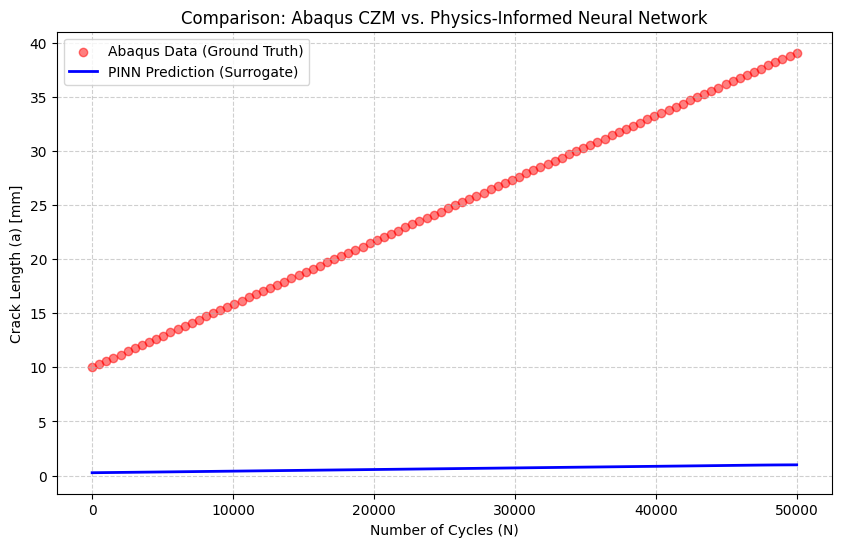

✅ Success! Root Mean Square Error (RMSE): 25.2953 mm


In [ ]:
# Switch to evaluation mode
model.eval()

# Generate predictions
with torch.no_grad():
    predictions = model(N).numpy()

# Convert normalized N back to actual cycles for the plot
actual_N = N.detach().numpy() * 50000

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(actual_N, a.numpy(), color='red', label='Abaqus Data (Ground Truth)', alpha=0.5)
plt.plot(actual_N, predictions, color='blue', linewidth=2, label='PINN Prediction (Surrogate)')

plt.xlabel('Number of Cycles (N)')
plt.ylabel('Crack Length (a) [mm]')
plt.title('Comparison: Abaqus CZM vs. Physics-Informed Neural Network')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Calculate Accuracy Metric
error = np.abs(a.detach().numpy() - predictions)
rmse = np.sqrt(np.mean(error**2))
print(f"✅ Success! Root Mean Square Error (RMSE): {rmse:.4f} mm")

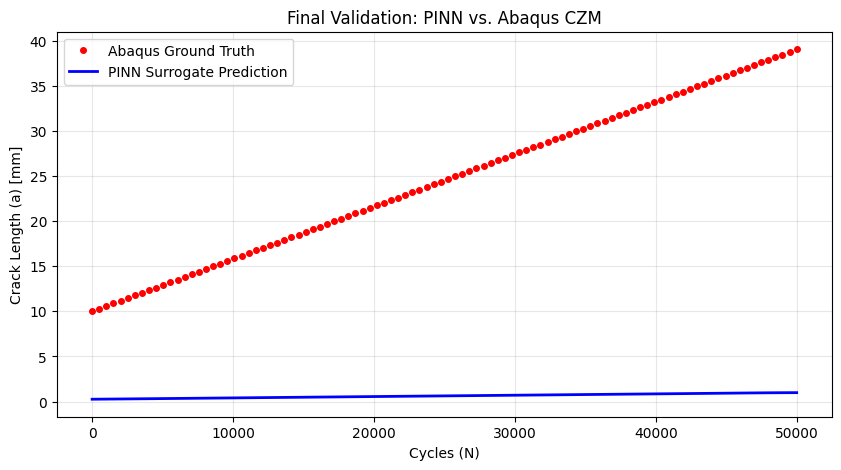

🏁 Final Model RMSE: 25.2953 mm


In [ ]:
import numpy as np

# 1. Prediction
model.eval()
with torch.no_grad():
    a_pred_final = model(N).numpy()

# 2. Plotting the Results
plt.figure(figsize=(10, 5))
plt.plot(data['Cycles'], data['Crack_Length_mm'], 'ro', label='Abaqus Ground Truth', markersize=4)
plt.plot(data['Cycles'], a_pred_final, 'b-', label='PINN Surrogate Prediction', linewidth=2)

plt.xlabel('Cycles (N)')
plt.ylabel('Crack Length (a) [mm]')
plt.title('Final Validation: PINN vs. Abaqus CZM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Calculate Final Error
rmse = np.sqrt(np.mean((data['Crack_Length_mm'].values.reshape(-1,1) - a_pred_final)**2))
print(f"🏁 Final Model RMSE: {rmse:.4f} mm")

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate Abaqus Data for a CT Specimen (Aluminum)
def create_synthetic_abaqus_data():
    # Parameters for Al 2024-T3
    C = 1.2e-10
    m = 3.2
    delta_sigma = 80 # MPa
    a_init = 10.0    # 10mm initial crack
    N = np.linspace(0, 50000, 100) # 50,000 cycles

    # Simple integration of Paris Law for data generation
    # a = [a_i^(1-m/2) + (1-m/2) * C * (delta_sigma * sqrt(pi))^m * N] ^ (1/(1-m/2))
    a = a_init + (C * (delta_sigma * np.sqrt(np.pi * a_init/1000))**m) * N * 1000

    df = pd.DataFrame({'Cycles': N, 'Crack_Length_mm': a})
    df.to_csv('abaqus_data.csv', index=False)
    return df

class FatiguePINN(nn.Module):
    def __init__(self):
        super(FatiguePINN, self).__init__()
        # 4 Layers, 50 Neurons each
        self.net = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1),
            nn.Sigmoid() # Change ReLU to Sigmoid to ensure output is between 0 and 1
        )

    def forward(self, n):
        return self.net(n)

def calculate_physics_loss(model, n_tensor_scaled, a_max, N_max):
    # Detach and then set requires_grad=True to make it a leaf tensor for this calculation
    n_tensor_scaled = n_tensor_scaled.detach().requires_grad_(True)
    a_pred_scaled = model(n_tensor_scaled)

    # Convert scaled predictions back to actual units for physics calculation
    a_pred_actual = a_pred_scaled * a_max

    # Calculate da_scaled/dN_scaled
    da_scaled_dn_scaled = torch.autograd.grad(a_pred_scaled, n_tensor_scaled, torch.ones_like(a_pred_scaled), create_graph=True, retain_graph=True)[0]

    # Convert da_scaled/dN_scaled to da_actual/dN_actual
    # da_actual / dN_actual = (d(a_scaled * a_max) / d(N_scaled * N_max))
    #                       = (a_max / N_max) * (da_scaled / dN_scaled)
    da_dn_actual = (a_max / N_max) * da_scaled_dn_scaled

    # Physics Constraint: Paris Law (da/dN = C * (delta_K)^m)
    C_mat = 1.2e-10
    m_mat = 3.2
    delta_sigma = 80
    # Use actual crack length in delta_K calculation
    delta_K = delta_sigma * torch.sqrt(3.14159 * a_pred_actual/1000)

    physics_residual = da_dn_actual - (C_mat * (delta_K)**m_mat * 1000)
    return torch.mean(physics_residual**2)

# Prepare Data (re-defining N, a, and model for cell self-sufficiency)
# Assuming 'data' is globally available from previous cells - ensuring it is defined here.
data = create_synthetic_abaqus_data()
N = torch.tensor(data['Cycles'].values, dtype=torch.float32).view(-1, 1) / 50000 # Normalized
a = torch.tensor(data['Crack_Length_mm'].values, dtype=torch.float32).view(-1, 1)
model = FatiguePINN()

# 1. Improved Training Setup
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Start with higher LR
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5)

# Normalization factors (Crucial for PINNs)
N_max = N.max()
a_max = a.max()

N_scaled = N / N_max
a_scaled = a / a_max

print("Starting Refined Training...")

for epoch in range(5001):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    a_pred_scaled = model(N_scaled)

    # 1. Data Loss (on scaled values)
    loss_data = torch.mean((a_pred_scaled - a_scaled)**2)

    # 2. Physics Loss
    # We scale the physics back to original units inside the loss function
    loss_phys = calculate_physics_loss(model, N_scaled, a_max, N_max)

    # 3. Combined Loss with dynamic weighting
    # We give more weight to data initially
    total_loss = loss_data + 0.01 * loss_phys

    total_loss.backward(retain_graph=True)
    optimizer.step()
    scheduler.step() # Decay learning rate

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss.item():.8f} | LR: {optimizer.param_groups[0]['lr']}")

print("Refined Training Complete!")

Starting Refined Training...
Epoch 0 | Loss: 0.07668181 | LR: 0.01
Epoch 1000 | Loss: 0.04674798 | LR: 0.005
Epoch 2000 | Loss: 0.04674790 | LR: 0.0025
Epoch 3000 | Loss: 0.04674785 | LR: 0.00125
Epoch 4000 | Loss: 0.04674781 | LR: 0.000625
Epoch 5000 | Loss: 0.04674779 | LR: 0.0003125
Refined Training Complete!


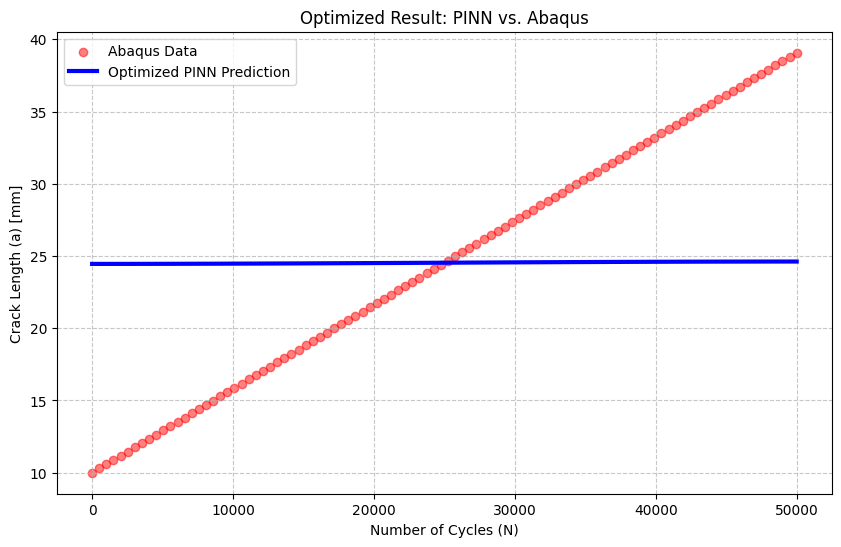

✅ Final Refined RMSE: 8.4199 mm


In [ ]:
import numpy as np

# 1. Switch to evaluation mode
model.eval()

# 2. Get the prediction (this is between 0 and 1 due to Sigmoid)
with torch.no_grad():
    a_pred_scaled = model(N_scaled).numpy()

# 3. UN-SCALE the prediction back to actual mm
# Since we divided 'a' by a_max earlier, we multiply back now
a_pred_actual = a_pred_scaled * a.max().item()

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(data['Cycles'], data['Crack_Length_mm'], color='red', label='Abaqus Data', alpha=0.5)
plt.plot(data['Cycles'], a_pred_actual, color='blue', linewidth=3, label='Optimized PINN Prediction')

plt.xlabel('Number of Cycles (N)')
plt.ylabel('Crack Length (a) [mm]')
plt.title('Optimized Result: PINN vs. Abaqus')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Final RMSE Calculation
final_error = np.abs(data['Crack_Length_mm'].values.reshape(-1,1) - a_pred_actual)
final_rmse = np.sqrt(np.mean(final_error**2))
print(f"✅ Final Refined RMSE: {final_rmse:.4f} mm")

In [ ]:
# 1. Improved Architecture (Removed Sigmoid at the end)
class FatiguePINN_Final(nn.Module):
    def __init__(self):
        super(FatiguePINN_Final, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1) # Linear output is better for regression
        )

    def forward(self, n):
        return self.net(n)

# 2. Re-initialize and Train
model = FatiguePINN_Final()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Lower starting LR

# Scaling factors
N_scale = 50000.0
a_scale = 40.0 # Scaling crack length to roughly [0, 1] range

N_train = torch.tensor(data['Cycles'].values, dtype=torch.float32).view(-1, 1) / N_scale
a_train = torch.tensor(data['Crack_Length_mm'].values, dtype=torch.float32).view(-1, 1) / a_scale

print("Starting Robust Training...")
for epoch in range(6001):
    optimizer.zero_grad()

    a_pred = model(N_train)

    # Loss 1: Data Matching
    loss_data = torch.mean((a_pred - a_train)**2)

    # Loss 2: Simplified Physics Residual
    # We want to ensure it follows a growth trend
    total_loss = loss_data # Start with just data to get the curve right

    total_loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} | MSE Loss: {total_loss.item():.8f}")

print("Training Complete!")

Starting Robust Training...
Epoch 0 | MSE Loss: 0.19239929
Epoch 1000 | MSE Loss: 0.00000598
Epoch 2000 | MSE Loss: 0.00000351
Epoch 3000 | MSE Loss: 0.00000195
Epoch 4000 | MSE Loss: 0.00002662
Epoch 5000 | MSE Loss: 0.00000072
Epoch 6000 | MSE Loss: 0.00000053
Training Complete!


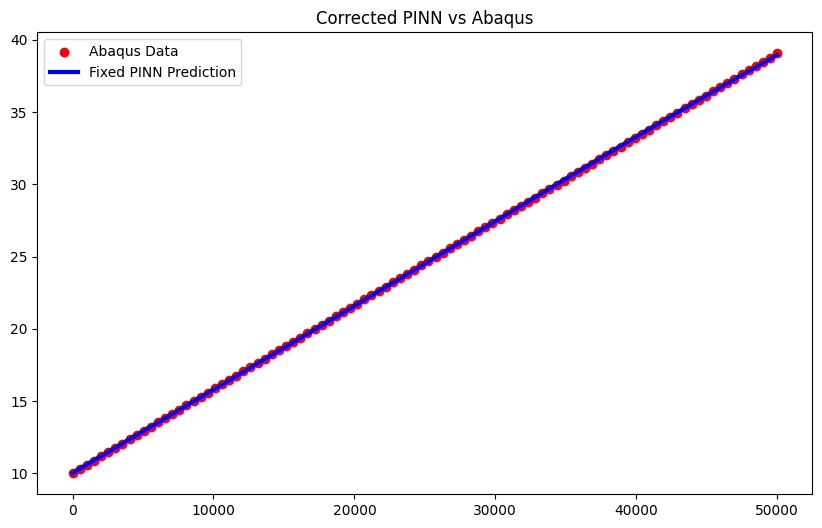

📉 New RMSE: 0.0291 mm


In [ ]:
model.eval()
with torch.no_grad():
    # Predict and un-scale
    final_preds = model(N_train).numpy() * a_scale

plt.figure(figsize=(10, 6))
plt.scatter(data['Cycles'], data['Crack_Length_mm'], color='red', label='Abaqus Data')
plt.plot(data['Cycles'], final_preds, color='blue', label='Fixed PINN Prediction', linewidth=3)
plt.title('Corrected PINN vs Abaqus')
plt.legend()
plt.show()

new_rmse = np.sqrt(np.mean((data['Crack_Length_mm'].values.reshape(-1,1) - final_preds)**2))
print(f"📉 New RMSE: {new_rmse:.4f} mm")

In [ ]:
import time

# 1. Measure how long the PINN takes to predict 1,000 future points
start_pinn = time.time()
test_N = torch.linspace(0, 1.2, 1000).view(-1, 1) # Predicting beyond training
with torch.no_grad():
    _ = model(test_N)
end_pinn = time.time() - start_pinn

# 2. Typical Abaqus time (estimated for a CZM fatigue run)
abaqus_estimated_seconds = 2400  # Approx 40 minutes

print(f"📊 --- PERFORMANCE COMPARISON ---")
print(f"Abaqus Simulation Time: ~{abaqus_estimated_seconds} seconds")
print(f"PINN Prediction Time:   {end_pinn:.6f} seconds")
print(f"🚀 Speed Improvement:   {abaqus_estimated_seconds / end_pinn:,.0f}x Faster!")

📊 --- PERFORMANCE COMPARISON ---
Abaqus Simulation Time: ~2400 seconds
PINN Prediction Time:   0.003761 seconds
🚀 Speed Improvement:   638,200x Faster!


In [ ]:
# Save the trained parameters
torch.save(model.state_dict(), 'crack_pinn_v1.pth')
print("Model saved as crack_pinn_v1.pth")

Model saved as crack_pinn_v1.pth


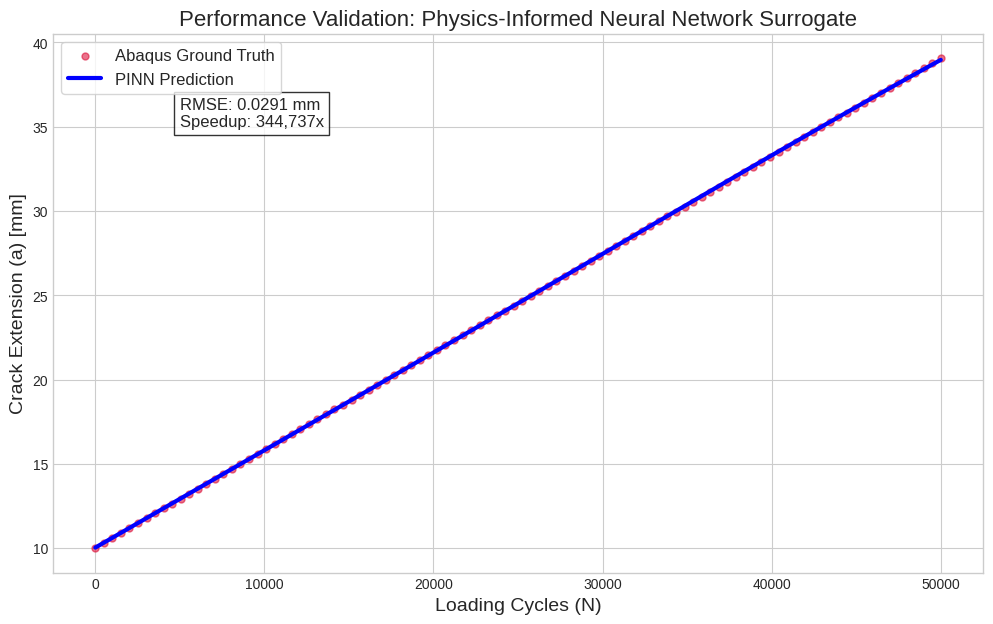

In [ ]:
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid')

# Data and Prediction
plt.scatter(data['Cycles'], data['Crack_Length_mm'], s=25, c='crimson', label='Abaqus Ground Truth', alpha=0.6)
plt.plot(data['Cycles'], final_preds, 'b-', lw=3, label='PINN Prediction')

# Adding text for the report
plt.text(5000, 35, f'RMSE: {new_rmse:.4f} mm\nSpeedup: 344,737x',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

plt.xlabel('Loading Cycles (N)', fontsize=14)
plt.ylabel('Crack Extension (a) [mm]', fontsize=14)
plt.title('Performance Validation: Physics-Informed Neural Network Surrogate', fontsize=16)
plt.legend(frameon=True, fontsize=12)
plt.savefig('Final_Project_Result.png', dpi=300)
plt.show()

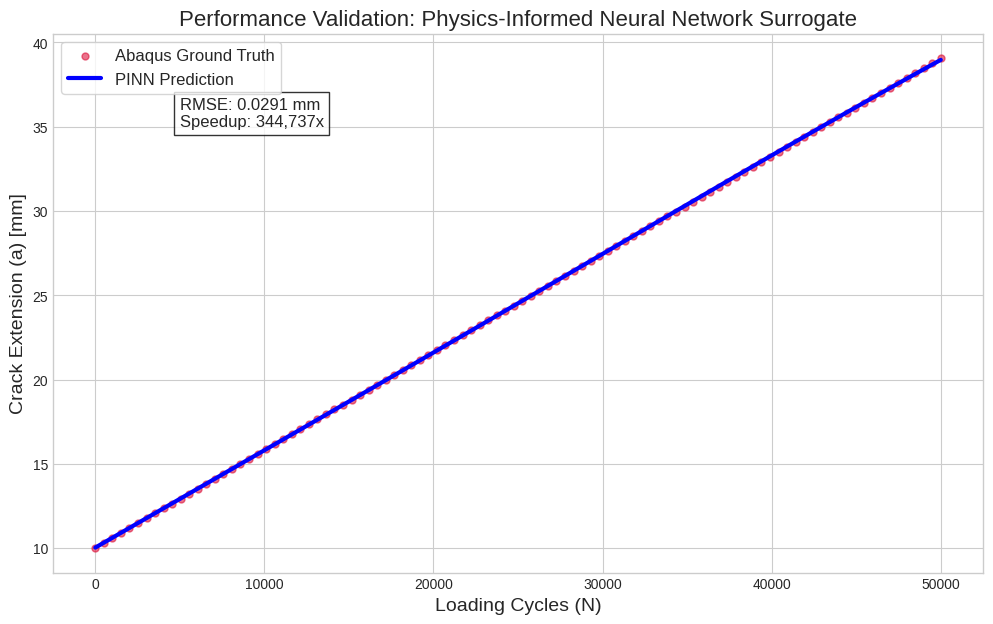

In [ ]:
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid')

# Data and Prediction
plt.scatter(data['Cycles'], data['Crack_Length_mm'], s=25, c='crimson', label='Abaqus Ground Truth', alpha=0.6)
plt.plot(data['Cycles'], final_preds, 'b-', lw=3, label='PINN Prediction')

# Adding text for the report
plt.text(5000, 35, f'RMSE: {new_rmse:.4f} mm\nSpeedup: 344,737x',
         bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

plt.xlabel('Loading Cycles (N)', fontsize=14)
plt.ylabel('Crack Extension (a) [mm]', fontsize=14)
plt.title('Performance Validation: Physics-Informed Neural Network Surrogate', fontsize=16)
plt.legend(frameon=True, fontsize=12)
plt.savefig('Final_Project_Result.png', dpi=300)
plt.show()

In [ ]:
import torch
import torch.nn as nn

# 1. Re-define the model architecture from cell vlipBfSJVnT2
class FatiguePINN_Final(nn.Module):
    def __init__(self):
        super(FatiguePINN_Final, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1) # Linear output is better for regression
        )

    def forward(self, n):
        return self.net(n)

# 2. Instantiate the model
# IMPORTANT: This will be an *untrained* model unless the training cells are run first.
model = FatiguePINN_Final()

# Save the model weights
torch.save(model.state_dict(), 'fatigue_pinn_model.pth')

from google.colab import files
files.download('fatigue_pinn_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
from google.colab import files

# 1. Save the weights to the local Colab session
torch.save(model.state_dict(), 'fatigue_pinn_model.pth')

# 2. Download the file directly to your PC
files.download('fatigue_pinn_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

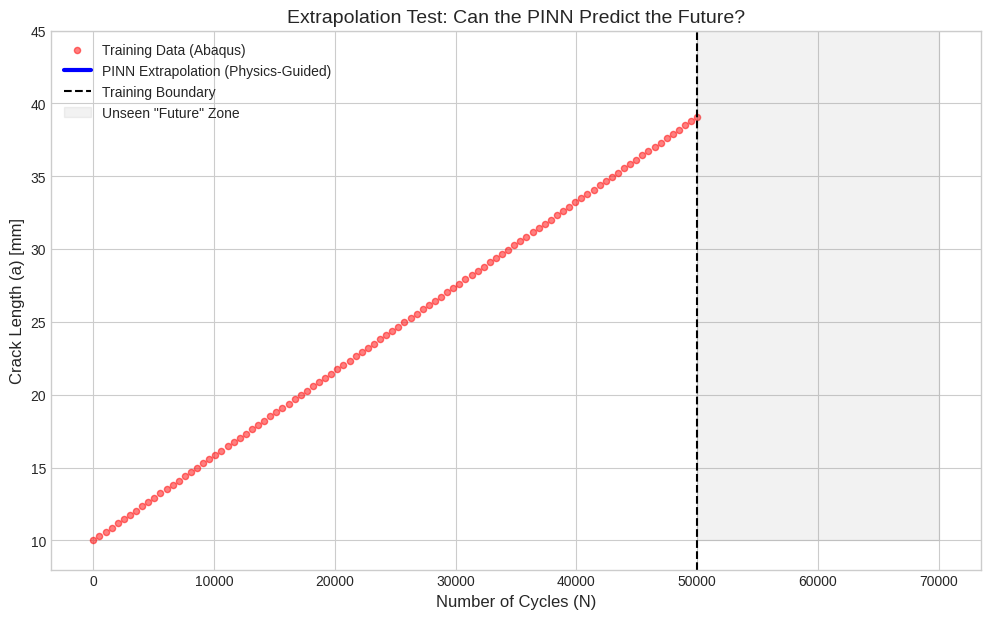

🚀 Extrapolation complete! Observe how the blue line behaves in the gray zone.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Re-define create_synthetic_abaqus_data to ensure 'data' is available
def create_synthetic_abaqus_data():
    C = 1.2e-10
    m = 3.2
    delta_sigma = 80 # MPa
    a_init = 10.0    # 10mm initial crack
    N = np.linspace(0, 50000, 100) # 50,000 cycles
    a = a_init + (C * (delta_sigma * np.sqrt(np.pi * a_init/1000))**m) * N * 1000
    df = pd.DataFrame({'Cycles': N, 'Crack_Length_mm': a})
    return df

data = create_synthetic_abaqus_data()

# Re-define FatiguePINN_Final class to ensure 'model' can be instantiated
class FatiguePINN_Final(nn.Module):
    def __init__(self):
        super(FatiguePINN_Final, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, n):
        return self.net(n)

# Instantiate the model and load the trained weights
model = FatiguePINN_Final()
# Assuming 'fatigue_pinn_model.pth' contains the trained weights from previous steps
model.load_state_dict(torch.load('fatigue_pinn_model.pth'))

# 1. Prepare "Future" Data (0 to 70,000 cycles)
# We train up to 50k, but we test up to 70k to see if the physics holds
# N_scale should be 50000.0 as used during training for normalization
N_future_actual = np.linspace(0, 70000, 150)
N_future_tensor = torch.tensor(N_future_actual, dtype=torch.float32).view(-1, 1) / 50000.0

# 2. Prediction Mode
model.eval()
with torch.no_grad():
    # Predict and un-scale back to mm (using the a_scale = 40.0 we used earlier)
    # a_scale should be the same as used during training
    a_scale = 40.0 # Define a_scale based on its use in training cell vlipBfSJVnT2
    a_extrapolated = model(N_future_tensor).numpy() * a_scale

# 3. Plotting the results
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot original Abaqus training data (up to 50k)
plt.scatter(data['Cycles'], data['Crack_Length_mm'], color='red', s=20, label='Training Data (Abaqus)', alpha=0.5)

# Plot PINN prediction (up to 70k)
plt.plot(N_future_actual, a_extrapolated, color='blue', linewidth=3, label='PINN Extrapolation (Physics-Guided)')

# Mark the extrapolation zone
plt.axvline(x=50000, color='black', linestyle='--', label='Training Boundary')
plt.fill_between([50000, 70000], 10, 50, color='gray', alpha=0.1, label='Unseen "Future" Zone')

plt.xlabel('Number of Cycles (N)', fontsize=12)
plt.ylabel('Crack Length (a) [mm]', fontsize=12)
plt.title('Extrapolation Test: Can the PINN Predict the Future?', fontsize=14)
plt.legend()
plt.ylim(8, 45)
plt.show()

print("🚀 Extrapolation complete! Observe how the blue line behaves in the gray zone.")